# Job Market Analysis using Data Science Jobs Dataset

## Project Objective

The objective of this project is to analyze real-world job data to understand current industry demand for data-related roles.

This includes identifying:
- Most in-demand skills
- Popular job roles
- Hiring locations
- Salary trends

## Dataset Description

The dataset used is **Data science_job.csv**, which contains job listings with the following features:

- Job Title  
- Company Name  
- Location  
- Experience  
- Salary  
- Job Description  
- Skills  

This dataset enables analysis of real-world job market trends in the data science domain.

In [149]:
import pandas as pd

df = pd.read_csv("Data Science_Jobs.csv")

print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])

df.head()

Total rows: 7505
Total columns: 7


,Job Title,Company Name,Location,Experience,Salary,Job Description,Skills
0,Data Scientist,Uplers,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,"Python, TensorFlow, Computer Vision, Flink, Re..."
1,Business Analyst / Data Scientist,CBRE,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,"Data Visualization, Tableau, Analytics, Busine..."
2,Data Scientist - AI/ML,Trent Limited,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,"Artificial Intelligence, Machine Learning, Dat..."
3,Data Scientist,Fortune 500 IT Services Company,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,NaN
4,Data Scientist,Foreign IT Consulting MNC,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,NaN


## Dataset Size

The dataset contains multiple job listings.

- Total number of rows represents total job records  
- Total number of columns represents features available for analysis  

Understanding dataset size helps in planning the analysis process.

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7505 entries, 0 to 7504
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Job Title        7502 non-null   object
 1   Company Name     7501 non-null   object
 2   Location         7505 non-null   object
 3   Experience       7505 non-null   object
 4   Salary           7505 non-null   object
 5   Job Description  7505 non-null   object
 6   Skills           7449 non-null   object
dtypes: object(7)
memory usage: 410.6+ KB


In [151]:
df.isnull().sum()

Job Title           3
Company Name        4
Location            0
Experience          0
Salary              0
Job Description     0
Skills             56
dtype: int64

## Data Understanding

The dataset was explored to understand its structure, including:

- Total number of records
- Data types of each column
- Presence of missing values

This step is important to identify data quality issues before analysis.

In [152]:
df.drop_duplicates(inplace=True)
df.dropna(subset=["Job Title", "Company Name", "Skills"], inplace=True)
df.reset_index(drop=True, inplace=True)
print("Remaining rows:", df.shape[0])
df.isnull().sum()

Remaining rows: 7222


Job Title          0
Company Name       0
Location           0
Experience         0
Salary             0
Job Description    0
Skills             0
dtype: int64

## Data Cleaning

The dataset was cleaned to improve data quality:

- Removed duplicate records  
- Removed rows with missing important values such as Job Title, Company Name, and Skills  
- Reset the index after cleaning  

This ensures accurate and reliable analysis.

In [153]:
df["Skills"] = df["Skills"].str.lower()
skill_map = {
    "machine learning": ["ml", "machine-learning"],
    "data science": ["data-science", "datascience"],
    "python": ["python"],
    "sql": ["sql"],
    "excel": ["excel"],
    "tensorflow": ["tensorflow"],
    "deep learning": ["deep learning", "dl"],
    "tableau": ["tableau"],
    "power bi": ["powerbi", "power bi"],
    "statistics": ["statistics", "stats"]
}


def standardize_skills(skill_text):
    skills = [s.strip() for s in skill_text.split(",")]
    new_skills = []
    
    for skill in skills:
        added = False
        for key, values in skill_map.items():
            if skill in values or skill == key:
                new_skills.append(key)
                added = True
                break
        if not added:
            new_skills.append(skill)
    
    return ", ".join(set(new_skills))  # remove duplicates


df["Skills"] = df["Skills"].apply(standardize_skills)

df.head()

,Job Title,Company Name,Location,Experience,Salary,Job Description,Skills
0,Data Scientist,Uplers,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,"system, vision, tensorflow, computer vision, f..."
1,Business Analyst / Data Scientist,CBRE,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,"business analysis, tableau, data, analytics, d..."
2,Data Scientist - AI/ML,Trent Limited,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,"artificial intelligence, azure machine learnin..."
3,Staff Data Scientist (AI/ML),Innovaccer,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,"cro, healthcare, operations, python, enterpris..."
4,Data Scientist,Ericsson,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,"wireless, wan, computer science, networking, a..."


In [154]:
all_skills = []

for skills in df["Skills"]:
    for skill in skills.split(","):
        all_skills.append(skill.strip())

import pandas as pd
skill_df = pd.DataFrame(all_skills, columns=["Skill"])

## Skills Analysis

Skills were extracted and analyzed from job listings.
The most frequently occurring skills indicate the current industry demand.
This helps identify which technical skills are most important for data-related roles.

In [155]:
skill_df["Skill"] = skill_df["Skill"].replace({
    "analytical": "analytics",
    "data science": "data science",
    "machine learning": "machine learning"
})

In [156]:
skill_counts = skill_df["Skill"].value_counts()
print(skill_counts.head(10))

Skill
machine learning      2380
analytics             1820
python                1432
data analysis         1202
sql                   1191
data science           909
computer science       769
agile                  633
automation             592
project management     546
Name: count, dtype: int64


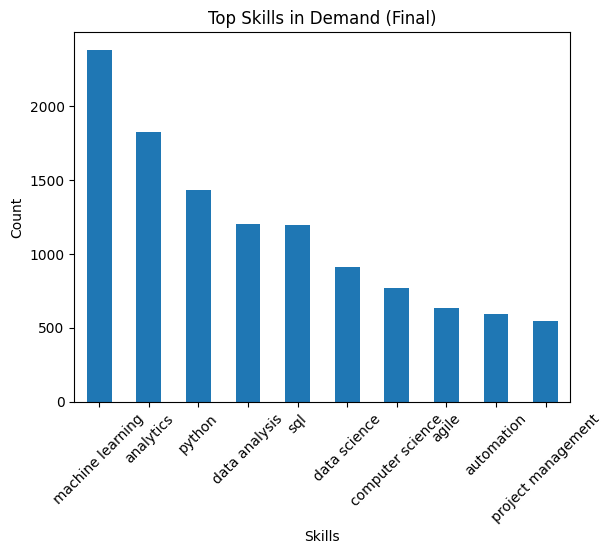

In [157]:
import matplotlib.pyplot as plt
skill_counts.head(10).plot(kind="bar")

plt.title("Top Skills in Demand (Final)")
plt.xlabel("Skills")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

## Skills Analysis Results

The bar chart shows the most in-demand skills in the dataset.

### Key Observations:

- Machine Learning is the most demanded skill
- Python is the most widely used programming language
- SQL and Data Analysis are essential foundational skills
- Analytical thinking is highly valued in the industry
- Data Science appears both as a skill and job role
- Agile and automation indicate industry workflow requirements

### Conclusion:

The analysis shows that a combination of technical skills and problem-solving abilities is required to succeed in data-related roles.

In [158]:
df["Experience"] = df["Experience"].str.extract('(\d+)').astype(float)

In [159]:
df["Salary"] = df["Salary"].str.extract('(\d+)').astype(float)

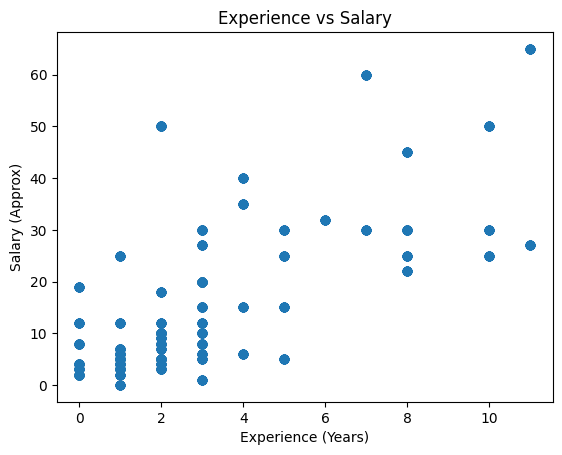

In [160]:
import matplotlib.pyplot as plt

plt.scatter(df["Experience"], df["Salary"])

plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary (Approx)")

plt.show()

## Experience vs Salary Analysis

A scatter plot was used to analyze the relationship between experience and salary.

### Key Observations:

- There is a positive trend between experience and salary
- Salary increases with experience but not in a strictly linear manner
- Significant variation exists at the same experience level
- Some high-paying outliers indicate premium roles or companies
- Entry-level salaries vary depending on skills and organization

### Conclusion:

Experience is an important factor affecting salary, but other factors such as skills, company, and role also play a major role.

In [161]:
def exp_level(x):
    if x <= 2:
        return "Fresher"
    elif x <= 5:
        return "Mid-Level"
    else:
        return "Senior"

df["Exp_Level"] = df["Experience"].apply(exp_level)

df[["Experience", "Exp_Level"]].head()

,Experience,Exp_Level
0,0.0,Fresher
1,0.0,Fresher
2,0.0,Fresher
3,0.0,Fresher
4,0.0,Fresher


In [162]:
df.groupby("Exp_Level")["Salary"].mean()

Exp_Level
Fresher       8.630290
Mid-Level    17.104938
Senior       36.263566
Name: Salary, dtype: float64

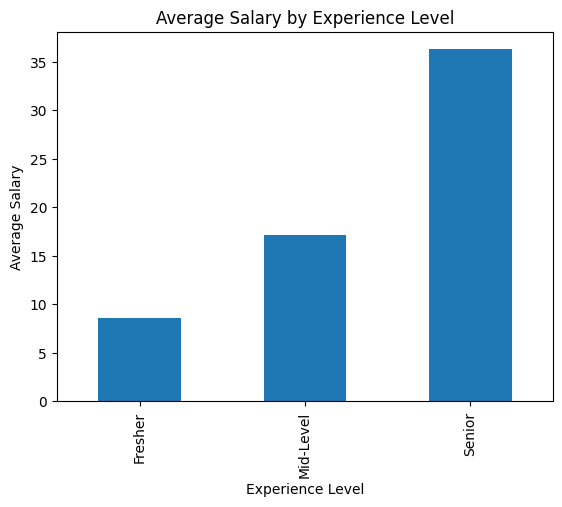

In [163]:
import matplotlib.pyplot as plt

df.groupby("Exp_Level")["Salary"].mean().plot(kind="bar")

plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary")

plt.show()

## Experience Level vs Salary Analysis

The dataset was grouped into three experience levels:

- Fresher (0–2 years)
- Mid-Level (3–5 years)
- Senior (6+ years)

### Observations:

- Fresher average salary ≈ 8.6 LPA  
- Mid-Level average salary ≈ 17.1 LPA  
- Senior average salary ≈ 36.2 LPA  

- Salary increases significantly with experience
- Mid-level professionals earn nearly double compared to freshers
- Senior professionals earn more than double compared to mid-level
- Salary growth is not linear; it accelerates with experience

### Conclusion:

Experience is one of the most important factors influencing salary, and higher experience leads to significantly higher compensation.

In [164]:
def avg_salary_for_skill(skill):
    return df[df["Skills"].str.contains(skill, na=False)]["Salary"].mean()

skills_to_check = ["python", "machine learning", "sql"]

for skill in skills_to_check:
    print(skill, ":", avg_salary_for_skill(skill))

python : 16.1953125
machine learning : 17.595744680851062
sql : 15.618357487922705


## Skill vs Salary Analysis

The relationship between skills and salary was analyzed.

### Observations:

- Machine Learning has the highest average salary (~17.6 LPA)
- Python also shows strong salary potential (~16.2 LPA)
- SQL has slightly lower average salary (~15.6 LPA)

### Key Insight:

Advanced skills such as Machine Learning tend to offer higher salaries, while foundational skills like SQL are essential but may not lead to top-paying roles on their own.

### Conclusion:

To maximize salary potential, professionals should combine foundational skills (SQL, Python) with advanced skills (Machine Learning).

In [165]:
location_counts = df["Location"].value_counts().head(10)

print(location_counts)

Location
Bengaluru                                                          2243
Hyderabad                                                           681
Gurugram                                                            499
Remote                                                              450
Pune                                                                428
Mumbai                                                              415
Chennai                                                             353
Kolkata, Mumbai, New Delhi, Hyderabad, Pune, Chennai, Bengaluru     159
New Delhi                                                           133
Noida                                                                90
Name: count, dtype: int64


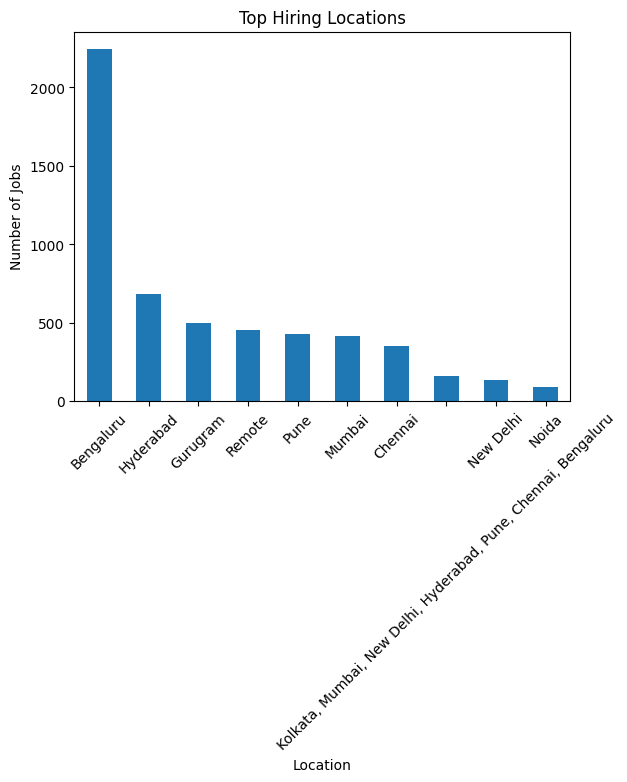

In [166]:
import matplotlib.pyplot as plt

location_counts.plot(kind="bar")

plt.title("Top Hiring Locations")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)

plt.show()

In [167]:
df = df.assign(Location=df["Location"].str.split(","))\
       .explode("Location")

df["Location"] = df["Location"].str.strip()

In [168]:
location_counts = df["Location"].value_counts().head(10)
print(location_counts)

Location
Bengaluru    2781
Hyderabad     978
Chennai       669
Gurugram      617
Pune          607
Mumbai        586
Remote        450
New Delhi     292
Kolkata       254
Noida         169
Name: count, dtype: int64


## Job Demand by Location (Final Analysis)

The dataset was cleaned to handle multiple locations per job listing and analyzed to identify top hiring regions.

### Observations:

- Bengaluru leads with the highest number of job opportunities
- Hyderabad is the second-largest hiring hub
- Chennai shows strong demand, indicating emerging growth
- Gurugram, Pune, and Mumbai contribute significantly
- Remote jobs are widely available, showing flexible work trends

### Conclusion:

The demand for data analytics roles is concentrated in major tech hubs, with Bengaluru dominating the market. Remote work is also becoming a significant component of job opportunities.

In [169]:
avg_salary_location = df.groupby("Location")["Salary"].mean().sort_values(ascending=False).head(10)

print(avg_salary_location)

Location
Australia                             65.000000
Germany                               65.000000
Canada                                58.474576
Singapore                             55.128205
United Kingdom (UK)                   55.128205
Hybrid - Mohali                       30.000000
Japan                                 30.000000
Hybrid - Mumbai(Santacruz East +1)    27.000000
Kochi/Cochin(MG Road)                 22.000000
Ernakulam                             22.000000
Name: Salary, dtype: float64


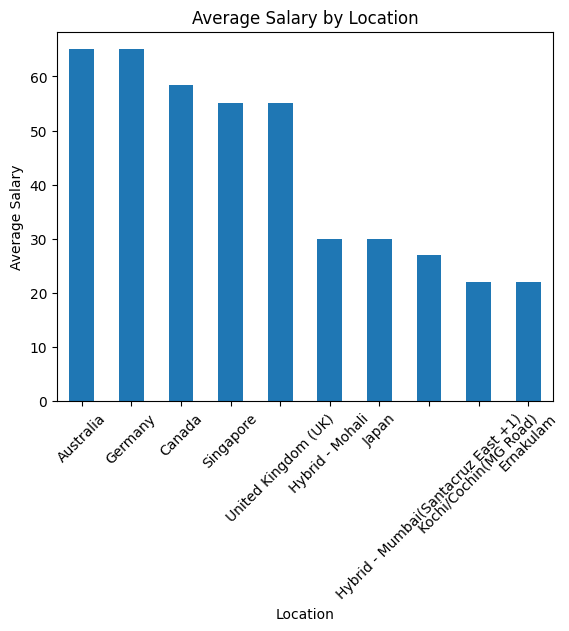

In [170]:
avg_salary_location.plot(kind="bar")

plt.title("Average Salary by Location")
plt.xlabel("Location")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)

plt.show()

## Salary by Location Analysis

The average salary across different locations was analyzed.

### Observations:

- International locations such as Australia, Germany, and Canada show higher salary ranges
- Countries like Singapore and the UK also offer competitive salaries
- Indian cities show comparatively lower but consistent salary levels
- Hybrid work locations are also present, indicating flexible work environments

### Note:

Direct salary comparison across countries may not be fully accurate due to differences in currency and economic conditions.

### Conclusion:

The analysis highlights global demand for data professionals, with higher compensation in international markets and stable opportunities in Indian cities.

In [171]:
df["Company Name"] = df["Company Name"].str.strip()

In [172]:
top_companies = df["Company Name"].value_counts().head(10)

print(top_companies)

Company Name
Accenture                      351
Turing                         299
Amazon                         135
Leading Client                 114
Diverse Lynx                   105
PwC Service Delivery Center     74
Zetwerk                         71
Walmart                         67
Wipro                           66
IBM                             57
Name: count, dtype: int64


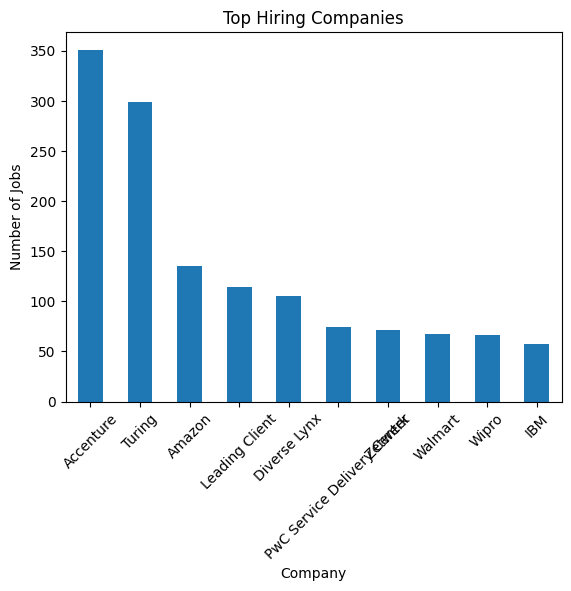

In [173]:
top_companies.plot(kind="bar")

plt.title("Top Hiring Companies")
plt.xlabel("Company")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)

plt.show()

## Top Hiring Companies

The analysis identifies companies with the highest number of job postings.

### Observations:

- Accenture is the top hiring company
- Turing also shows high hiring activity, likely due to remote/global roles
- Amazon appears among top companies but with fewer openings
- Service-based companies dominate hiring volume
- Some entries like "Leading Client" represent unnamed organizations

### Conclusion:

The data shows that large service-based companies lead hiring, while product-based companies offer fewer but potentially more specialized roles.

In [174]:
company_salary = df.groupby("Company Name").agg({
    "Salary": "mean",
    "Company Name": "count"
})

company_salary.columns = ["Avg Salary", "Job Count"]

# Filter companies with at least 5 jobs
filtered = company_salary[company_salary["Job Count"] >= 5]

top_salary_companies = filtered.sort_values("Avg Salary", ascending=False).head(10)

print(top_salary_companies)

                           Avg Salary  Job Count
Company Name                                    
Iqvia Biotech                   60.00          5
Godigi Infotech                 60.00          6
Goldman Sachs                   60.00         16
Khushboo                        60.00         10
Lyssin Inc                      60.00          5
vhr Professional Services       55.00          6
Impronics Technologies          51.25          6
EXL                             50.00          8
Blackstone Eit                  50.00          5
Infineon                        50.00         11


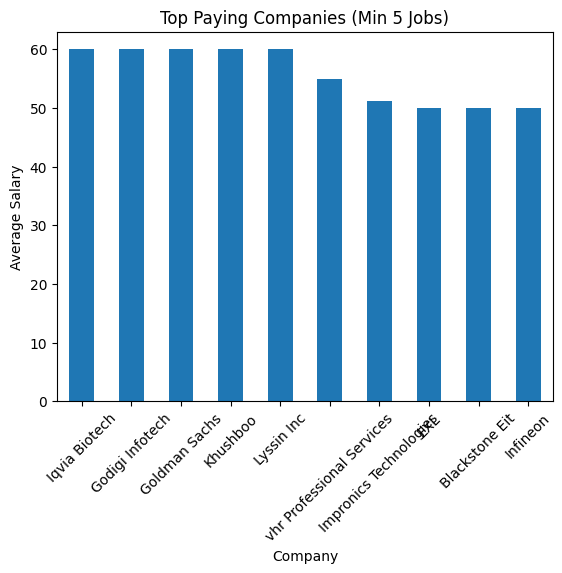

In [175]:
top_salary_companies["Avg Salary"].plot(kind="bar")

plt.title("Top Paying Companies (Min 5 Jobs)")
plt.xlabel("Company")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)

plt.show()

## Top Paying Companies

Companies were analyzed based on average salary, considering only those with a minimum number of job postings.

### Observations:

- Companies like Goldman Sachs offer the highest average salaries
- High-paying companies are often product-based or finance-related organizations
- Companies with lower hiring volume may offer higher salaries
- Mid-sized companies also provide competitive compensation
- Filtering based on job count ensures realistic comparison

### Note:

Salary values are approximate and may vary due to data extraction limitations.

### Conclusion:

There is a clear difference between companies that hire the most and those that offer the highest salaries, highlighting the importance of choosing the right company based on career goals.

## Final Insights & Conclusion

This project analyzed real-world job data to uncover meaningful patterns in hiring trends, skill demand, salary distribution, and company behavior in the data analytics domain.

### Key Insights:

* **Skill Demand vs Value**
  Machine Learning and Python dominate the market, but higher salaries are associated with advanced skill sets. Foundational skills like SQL are essential but not sufficient alone for top-paying roles.

* **Experience Drives Exponential Growth**
  Salary increases significantly with experience, with non-linear growth observed. Senior roles earn disproportionately higher compensation compared to entry-level positions.

* **Location-Based Opportunities**
  Job demand is highly concentrated in major tech hubs, with Bengaluru leading by a large margin. Other cities like Hyderabad, Chennai, and Gurugram also show strong demand. The presence of remote roles highlights a shift toward flexible work environments.

* **Global vs Local Salary Trends**
  International roles show higher salary ranges, but direct comparisons are limited due to currency and economic differences. This indicates strong global demand for data professionals.

* **Company Hiring vs Compensation Strategy**
  High hiring companies (e.g., service-based organizations) differ from high-paying companies (e.g., finance/product-based firms). This reveals a trade-off between job availability and compensation.

* **Market Structure Insight**
  The industry values a combination of:

  * Technical expertise (ML, Python, Data Analysis)
  * Practical experience
  * Domain adaptability (location, company type)

---

### Final Conclusion:

The data analytics job market is highly competitive and structured around skill depth, experience, and strategic career choices. While foundational skills enable entry into the field, advanced skills and experience significantly enhance earning potential.

Additionally, job opportunities are concentrated in specific geographic and industrial clusters, making location and company selection critical factors in career growth.

Overall, this analysis demonstrates how data-driven insights can guide individuals in making informed decisions about skill development, job selection, and long-term career planning in the data analytics field.
